In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
import tensorflow as tf
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler



Classic libraries added.

In [2]:
train_dir = "/kaggle/input/friendspersondataset/friends-dataset/train"
test_dir = "/kaggle/input/friendspersondataset/friends-dataset/validation"
print(os.listdir(train_dir))




['ross-geller', 'monica-geller', 'chandler-bing', 'phoebe-buffay', 'rachel-green', 'joey-tribbiani']


This code returns the names of the folders in the specified directory. Each folder represents a character.

In [3]:
label = []
path = []

for dir_name, _, filenames in os.walk(train_dir):
    for filename in filenames:
        if dir_name.split()[-1]!='GT':
            if os.path.splitext(filename)[-1]=='.png':
                label.append(os.path.split(dir_name)[-1])
                path.append(os.path.join(dir_name, filename))
                
data = pd.DataFrame(columns=['path','label'])
data['path']=path
data['label']=label
data


,path,label
0,/kaggle/input/friendspersondataset/friends-dat...,ross-geller
1,/kaggle/input/friendspersondataset/friends-dat...,ross-geller
2,/kaggle/input/friendspersondataset/friends-dat...,ross-geller
3,/kaggle/input/friendspersondataset/friends-dat...,ross-geller
4,/kaggle/input/friendspersondataset/friends-dat...,ross-geller
...,...,...
369,/kaggle/input/friendspersondataset/friends-dat...,joey-tribbiani
370,/kaggle/input/friendspersondataset/friends-dat...,joey-tribbiani
371,/kaggle/input/friendspersondataset/friends-dat...,joey-tribbiani
372,/kaggle/input/friendspersondataset/friends-dat...,joey-tribbiani


This code scans all the image files and labels in the dataset and exports them to a Pandas DataFrame.

os.walk() scans all the folders and files in the directory. Files with the .png extension (character images) are filtered. The path of each image is recorded as path and the folder where the image is located is recorded as label. Finally, this information is exported to a DataFrame.

In [4]:
print("number of images:", len(data))

print("number of images per character:", data.label.value_counts())

number of images: 374
number of images per character: label
joey-tribbiani    75
chandler-bing     69
phoebe-buffay     69
monica-geller     58
ross-geller       56
rachel-green      47
Name: count, dtype: int64


The first row reflects the total amount in the dataset.

The second row shows the number of occurrences of his character (number of occurrences). The data.label.value_counts() command counts the number of occurrences of his character.

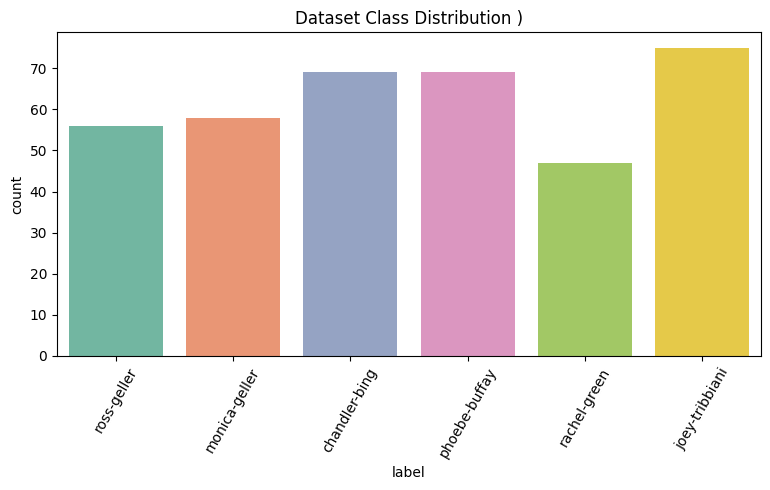

In [5]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)

sns.countplot(data=data, x='label', palette='Set2')  
plt.xticks(rotation=60) 
plt.title('Dataset Class Distribution )') 

plt.tight_layout() 
plt.show()

    This code visualizes the distribution of visual types in the dataset.

sns.countplot: Displays the number of characters (number of images) in the label column with a bar chart.

plt.xticks(rotation=60): Rotates 60 degrees to see the names of the characters more clearly.

plt.title: Adds a title to the chart.

plt.tight_layout(): Used to prevent sub-charts from interfering with each other and to provide a tidy appearance.

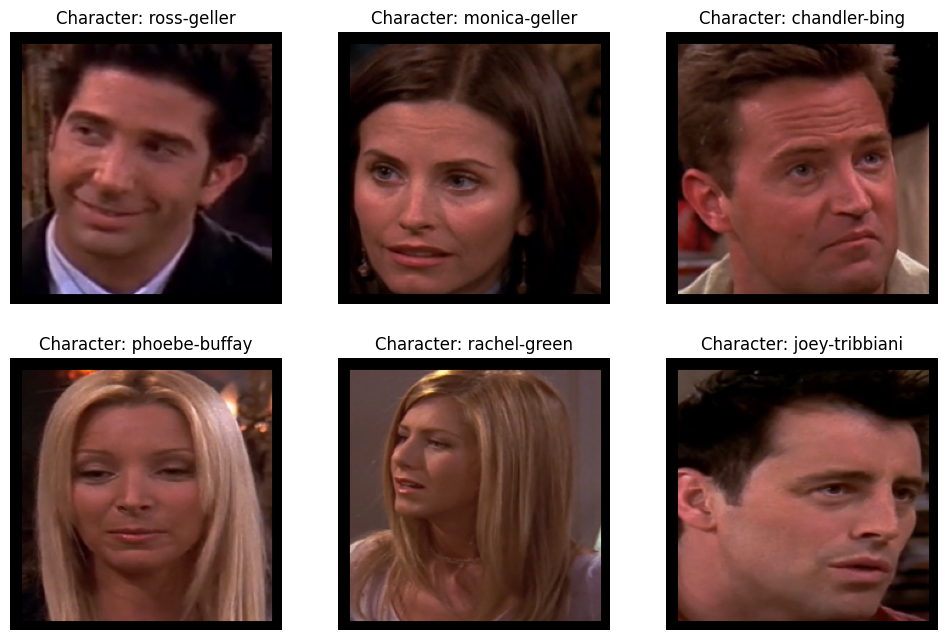

In [6]:
i = 0 
plt.figure(figsize=(12,12))

for unique_label in data['label'].unique():
    plt.subplot(3, 3, i + 1)
    img_path = data[data['label'] == unique_label].iloc[0, 0]
    img = plt.imread(img_path) 
    plt.imshow(img)
    plt.title(f"Character: {unique_label}")
    ax = plt.gca()
    ax.add_patch(plt.Rectangle((0, 0), img.shape[1], img.shape[0], 
                               edgecolor='black', fill=False, lw=15))
    plt.axis('off')
    i+= 1
plt.show()

This code visually introduces the types by displaying a sample of each character.

plt.subplot(3, 3, i + 1): Allocates a display area for each type in a 3x3 matrix structure.

data['label'] == unique_label: Only one sample image is taken for each character.

plt.imshow(img): Prints the image file to the screen.

plt.title: Shows the name of the character on the image.

plt.axis('off'): Hide the axes.

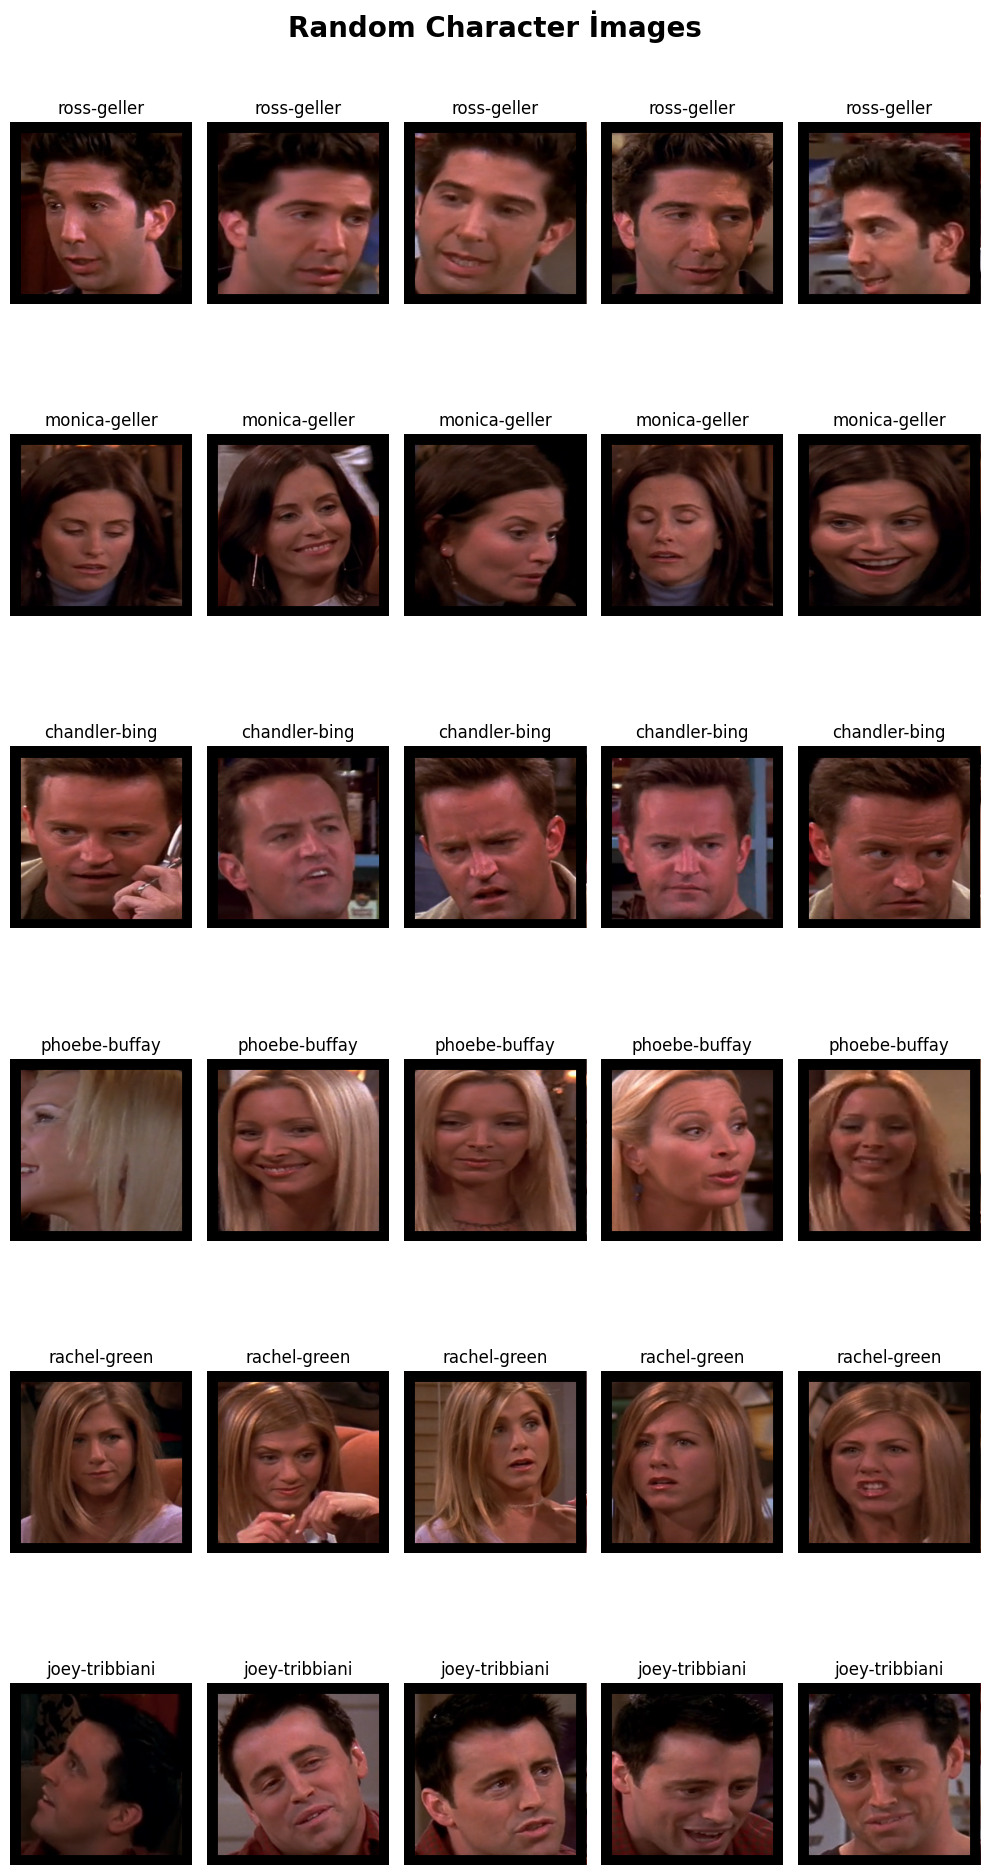

In [7]:
person_types = ['ross-geller' , 'monica-geller' , 'chandler-bing' , 'phoebe-buffay' , 'rachel-green' , 'joey-tribbiani']

plt.figure(figsize=(10, 20)) 
plt.suptitle("Random Character İmages", fontsize=20, fontweight='bold')

i = 0

for person in person_types:
    person_images = data[data['label'] == person].sample(5).path
    
    for person_image in person_images:
        plt.subplot(len(person_types), 5, i + 1)
        img = plt.imread(person_image)
        plt.imshow(img)
        plt.title(person) 
        plt.axis("off")
        
        ax = plt.gca()
        ax.add_patch(plt.Rectangle((0, 0), img.shape[1], img.shape[0], edgecolor='black', fill=False, lw=15))
        
        i += 1

plt.tight_layout()
plt.show()

This code selects 5 random images from each character type and visualizes the images by arranging them one below the other.

In [8]:
train_data, test_data = train_test_split(data, test_size=0.2, shuffle=True, random_state=42)

print(train_data.shape)
print(test_data.shape)

(299, 2)
(75, 2)


It splits the dataset into training and testing. 80% of the data is used for training and 20% for testing. 
The train_test_split function randomly shuffles the data and the random_state=42 parameter is used to provide a fixed randomness. This ensures that the same split is obtained again.

In [9]:
train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    validation_split=0.2  
)

test_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input  
)


train_images = train_generator.flow_from_dataframe(
    dataframe=train_data,  
    x_col='path',  
    y_col='label',  
    target_size=(224, 224),  
    color_mode='rgb',  
    class_mode='categorical',  
    batch_size=32,  
    shuffle=True, 
    seed=42, 
    subset='training' 
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_data,  
    x_col='path',
    y_col='label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation' 
)


test_images = test_generator.flow_from_dataframe(
    dataframe=test_data,  
    x_col='path', 
    y_col='label',
    target_size=(224, 224), 
    color_mode='rgb', 
    class_mode='categorical',  
    batch_size=32, 
    shuffle=False  
)

Found 240 validated image filenames belonging to 6 classes.


Found 59 validated image filenames belonging to 6 classes.


Found 75 validated image filenames belonging to 6 classes.


Data streams are prepared for training, validation and test data sets with ImageDataGenerator. Data augmentation operations are applied to the training set. 

Images are converted to 224x224 size, resized and processed in RGB format. In addition, 20% of the training data is separated as validation data.

In [10]:
display(train_images.class_indices)
display(val_images.class_indices)
display(test_images.class_indices)


{'chandler-bing': 0,
 'joey-tribbiani': 1,
 'monica-geller': 2,
 'phoebe-buffay': 3,
 'rachel-green': 4,
 'ross-geller': 5}

{'chandler-bing': 0,
 'joey-tribbiani': 1,
 'monica-geller': 2,
 'phoebe-buffay': 3,
 'rachel-green': 4,
 'ross-geller': 5}

{'chandler-bing': 0,
 'joey-tribbiani': 1,
 'monica-geller': 2,
 'phoebe-buffay': 3,
 'rachel-green': 4,
 'ross-geller': 5}

With class_indices we display the class labels (indices) assigned to each character type. These indices indicate which class the model assigned to which character type.

In [11]:
# Define a simple neural network model (irregular fully connected layers)
model = Sequential([

    # input layer
    Flatten(input_shape=(224, 224, 3)), 

    # 1. layer
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # 2. layer
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # 3. layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # output layer
    Dense(len(train_images.class_indices), activation='softmax')  
])

#compile the model
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

# print model summary
model.summary()

Model: "sequential"


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 150528)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      77,070,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,239,430 (294.65 MB)

 Trainable params: 77,237,638 (294.64 MB)

 Non-trainable params: 1,792 (7.00 KB)


Bu kısımda basit bir yapay sinir ağı modeli tanımlanır.
İlk katman giriş verisini alır ve Flatten işlemi ile 224x224 boyutlu görüntüleri düzleştirir. 
Her katman, relu aktivasyon fonksiyonu ve droxout işlemi ile düzenlenir. 
Çıkış katmanı, softmax fonksiyonu kullanarak sınıflandırma yapar.
Model, Adam optimizasyon algoritması ve categorical_crossentropy kayıp fonksiyonu ile derlenir.

In [ ]:
#Early stopping mechanism
early_stopping = EarlyStopping(
    monitor='val_loss',  
    patience=5,  
    restore_best_weights=True  
)

#Learning rate planner
def lr_scheduler(epoch, lr):
    if epoch >= 10:  
        return lr * 0.95
    return lr

lr_scheduler_callback = LearningRateScheduler(lr_scheduler)

# compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  
    loss='categorical_crossentropy',  
    metrics=['accuracy']  
)

#Training the model on GPU
with tf.device('/GPU:0'):  
    history = model.fit(
        train_images,  
        epochs=30,  
        batch_size=32,  
        validation_data=val_images, 
        callbacks=[early_stopping, lr_scheduler_callback]  
    )

# Evaluation of training results
plt.figure(figsize=(12, 5))

#Training and validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

#Training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

The model is trained for 30 epochs and optimization techniques such as early stopping and learning rate scheduler are used. During the training process of the model, val_loss is monitored against the validation data. If the model performance does not improve over a certain period of time, training is stopped and the best weights are restored.

The loss and accuracy values ​​obtained during the training process are shown on the graph. These graphs visualize how the model improves its performance over time (over epochs) on the training and validation sets. The differences between the training and validation curves help understand whether the model is overfitting.

In [ ]:
#Evaluating the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_images, verbose=0)
print(f"\n[Overall Test Results]")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

#Calculating estimates
y_pred = model.predict(test_images, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)  
y_true = test_images.labels  

#Getting class names
class_names = test_images.class_indices  
class_names = list(class_names.keys()) 

#Class-based performance report
print("\n[Classification Report]")
print(classification_report(y_true, y_pred_classes))

#Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

#Visualizing the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


I was able to visually evaluate the model's predictive performance and analyze its shortcomings on a class basis.

In [ ]:
#Accuracy Score
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

predict_data = pd.DataFrame({
    'label': test_images.classes,  
    'pred': predicted_labels      
})


print(f"Accuracy Score: {accuracy_score(predict_data['label'], predict_data['pred'])}")

Calculating Accuracy Score In this step, the model calculates its accuracy on the test dataset. The model's predictions on the test dataset are compared with the real labels using the accuracy_score metric. This metric shows how successful the model is on the test data. The accuracy score is calculated on a percentage basis.

In this experiment, our accuracy score was calculated as 76%.

In [ ]:
# Save the model
model.save('/kaggle/working/friends-person-recognition.h5')

# Load the model
model = load_model('/kaggle/working/friends-person-recognition.h5')


In [ ]:
print(os.listdir('/kaggle/working'))  


I saved and loaded the model, then I listed the files in the working directory with the os.listdir code to make sure the model was loaded.

In [ ]:
#Receiving images from the user
def load_user_image(file_path):
    image = cv2.imread(file_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

#Image processing
def preprocess_image(image, target_size=(224, 224)):
    resized_image = cv2.resize(image, target_size)
    preprocessed_image = resized_image / 255.0 
    return np.expand_dims(preprocessed_image, axis=0)

# Guessing
def predict_character(image_path):
  
    user_image = load_user_image(image_path)

    processed_image = preprocess_image(user_image)

    predictions = model.predict(processed_image)
    predicted_label = np.argmax(predictions, axis=1)

    return predicted_label, user_image

#Visualize results
def display_result(image, label, class_names):
    plt.imshow(image)
    plt.title(f"Predicted Character: {class_names[label[0]]}")
    plt.axis('off')
    plt.show()


This code takes an image from the user and performs a prediction process with the help of a specific model. First, the image file is read with the load_user_image function and the color format is converted to RGB. Then, it is resized, normalized and made suitable for the model's input with the preprocess_image function. The predict_character function sends the processed image to the model and returns the predicted class label. Finally, the display_result function visualizes the original image with the predicted class name.

In [ ]:
# Receive and process files from the user
image_path = input("Enter the path to the image: ")
predicted_label, user_image = predict_character(image_path)

# Character class names
class_names = ['Chandler', 'Joey', 'Monica', 'Phoebe', 'Rachel', 'Ross'] 


#Show estimate
display_result(user_image, predicted_label, class_names)